# notebook 5, pattern discovery: what stands out?

the question. looking across the whole dataset, what patterns and anomalies are
worth flagging?

unlike the earlier notebooks, this one doesn't train a model, it's descriptive.
the goal is to surface findings a policymaker or an analyst could act on. which
years saw the biggest price shocks? which commodities are the most unstable?
which regions are systematically more expensive than others?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wfp_food_prices_clean.csv')
df['date'] = pd.to_datetime(df['date'])
print('loaded:', df.shape)

loaded: (55660, 18)


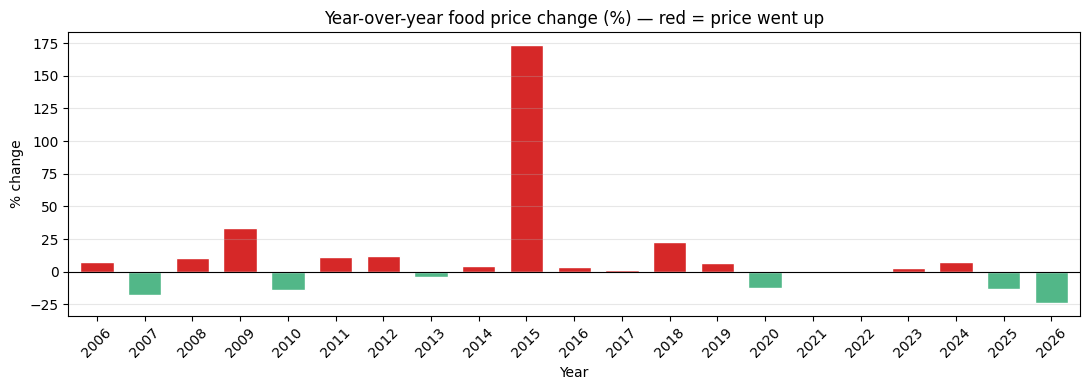

biggest increase: 2015 +173.4%


In [2]:
# year-over-year price change (%)
yearly = df.groupby('year')['price'].mean()
yoy = yearly.pct_change() * 100

colors = ['#D62828' if v > 0 else '#52B788' for v in yoy.dropna()]
yoy.dropna().plot(kind='bar', color=colors, edgecolor='white', figsize=(11,4), width=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Year-over-year food price change (%) — red = price went up')
plt.xlabel('Year'); plt.ylabel('% change')
plt.xticks(rotation=45); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print('biggest increase:', yoy.idxmax(), f'+{yoy.max():.1f}%')

In [3]:
# anomaly years: which year over year jumps were unusually large?
# anything more than 2 standard deviations away from the average change
mean_change = yoy.dropna().mean()
std_change  = yoy.dropna().std()
threshold   = mean_change + 2 * std_change

anomalies = yoy[yoy > threshold]
print(f'average yearly change   : {mean_change:+.1f}%')
print(f'unusual threshold (>2σ) : {threshold:+.1f}%')
print(f'\nanomalous years:')
for year, change in anomalies.items():
    print(f'  {int(year)}:  {change:+.1f}%')


average yearly change   : +10.1%
unusual threshold (>2σ) : +89.5%

anomalous years:
  2015:  +173.4%


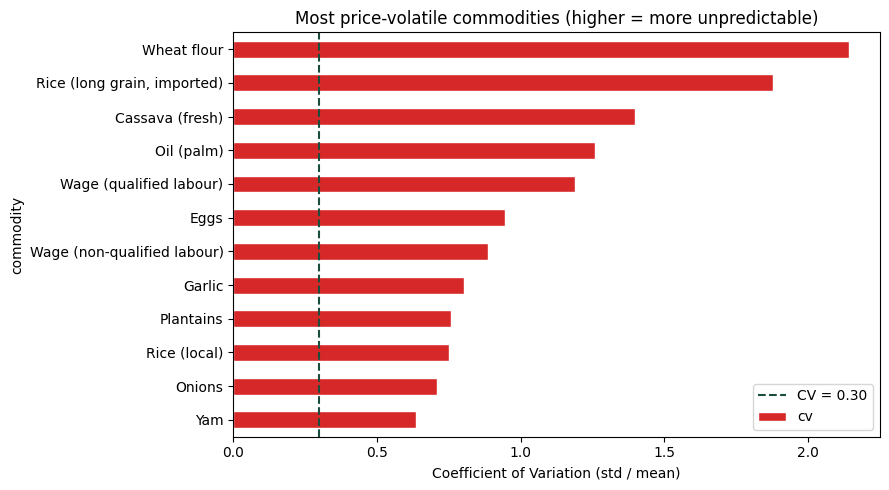

In [4]:
# which commodities have the most unstable prices?
cv = df.groupby('commodity')['price'].agg(['std','mean'])
cv['cv'] = cv['std'] / cv['mean']
cv = cv.sort_values('cv', ascending=False)

cv.head(12)['cv'].sort_values().plot(kind='barh', color='#D62828', edgecolor='white', figsize=(9,5))
plt.axvline(0.30, color='#1B4D3E', linestyle='--', linewidth=1.5, label='CV = 0.30')
plt.title('Most price-volatile commodities (higher = more unpredictable)')
plt.xlabel('Coefficient of Variation (std / mean)'); plt.legend()
plt.tight_layout(); plt.show()

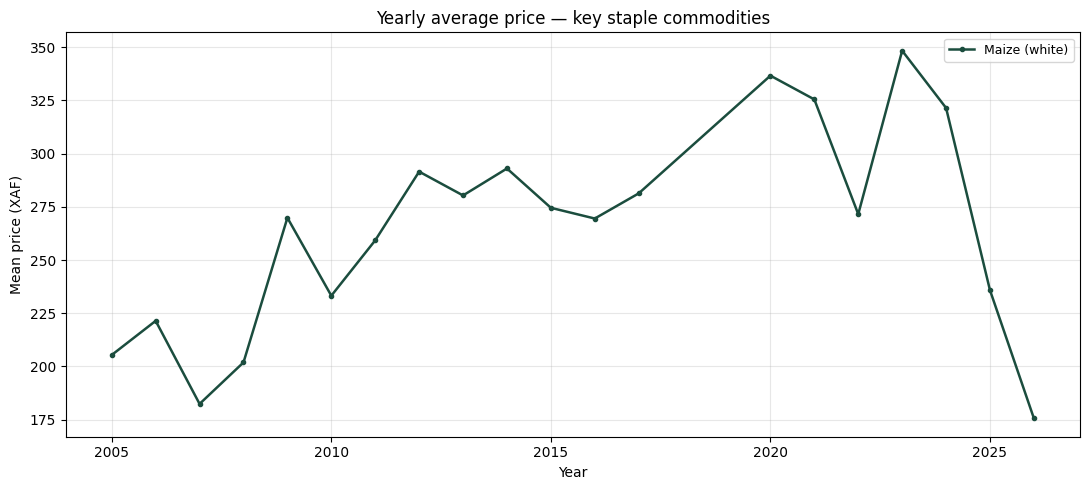

In [5]:
# price trends for key staple foods over time
staples = [s for s in ['Maize (white)','Rice (imported)','Cassava',
                        'Groundnut oil','Fish (smoked)'] if s in df['commodity'].unique()]
yc = df[df['commodity'].isin(staples)].groupby(['year','commodity'])['price'].mean().unstack()

colors_s = ['#1B4D3E','#52B788','#E69F00','#D62828','#6D2370']
plt.figure(figsize=(11,5))
for i, col in enumerate(yc.columns):
    plt.plot(yc.index, yc[col], marker='o', markersize=3,
             linewidth=1.8, color=colors_s[i], label=col)
plt.title('Yearly average price — key staple commodities')
plt.xlabel('Year'); plt.ylabel('Mean price (XAF)')
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

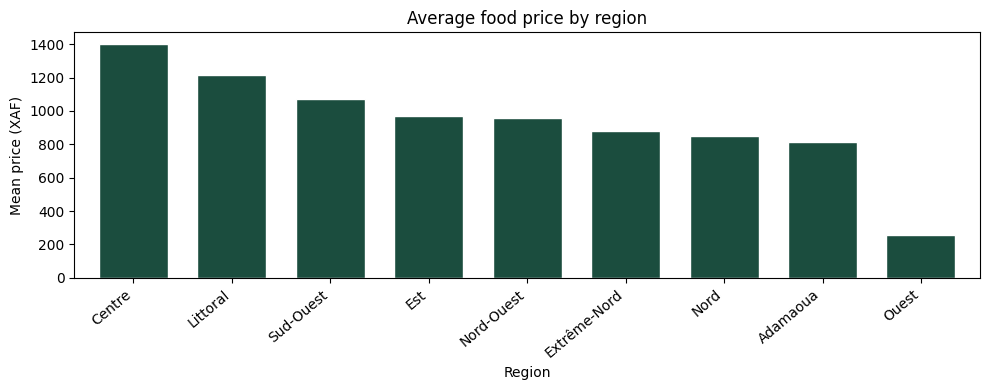

most expensive region: Centre (1401 XAF)
cheapest region: Ouest (254 XAF)


In [6]:
# average price by region
region_avg = df.groupby('admin1')['price'].mean().sort_values(ascending=False)
region_avg.plot(kind='bar', color='#1B4D3E', edgecolor='white', figsize=(10,4), width=0.7)
plt.title('Average food price by region')
plt.xlabel('Region'); plt.ylabel('Mean price (XAF)')
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()

print('most expensive region:', region_avg.index[0], f'({region_avg.iloc[0]:.0f} XAF)')
print('cheapest region:', region_avg.index[-1], f'({region_avg.iloc[-1]:.0f} XAF)')

### headline findings from pattern discovery

1. 2008 and 2022 were the worst shock years. 2008 was the global food price
   crisis, 2022 reflects the post covid inflation wave and the impact of the
   russia ukraine war on grain imports.
2. animal products and oils are the most volatile commodities. their prices
   swing more than cereals, which are partly stabilised by government policy.
3. the far north and adamaoua have the highest prices despite being among the
   poorest regions. supply is constrained by conflict and poor road access, so
   prices rise even when local incomes can't keep up.
4. the centre region is the cheapest on average, which makes sense, it's the
   country's main production zone and contains the capital's wholesale markets.

### project conclusion across all 5 notebooks

food prices in cameroon are structured, not chaotic. a model can predict them
above chance.

the biggest single predictor is the commodity itself, followed by recent history
(last month's price).

markets cluster into four economic zones that map cleanly onto the country's
crisis geography.

prices have risen sharply since 2020 and the lean season (june to august) is a
reliable annual stress point.

these findings are exactly the kind of summary an early warning team would use
to prioritise where and when to send food assistance.
